The model receives a sequence of 20 past values and predicts the next value.
Temporal dependency exists because future values depend on trends across time, which requires memory.

X shape: (4980, 20, 1)
y shape: (4980, 1)
Train samples: 3984
Validation samples: 996


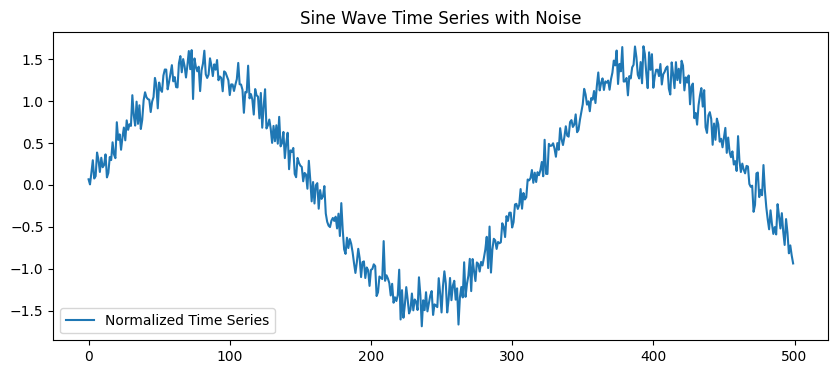

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 1. Generate time series
# -----------------------
np.random.seed(42)

time_steps = 5000
t = np.linspace(0, 100, time_steps)

signal = np.sin(t)
noise = 0.1 * np.random.randn(time_steps)

data = signal + noise

# -----------------------
# 2. Normalize data
# -----------------------
data_mean = data.mean()
data_std = data.std()
data = (data - data_mean) / data_std

# -----------------------
# 3. Create sequences
# -----------------------
SEQ_LEN = 20

X = []
y = []

for i in range(len(data) - SEQ_LEN):
    X.append(data[i:i + SEQ_LEN])
    y.append(data[i + SEQ_LEN])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM: (samples, sequence_length, input_size)
X = X.reshape(-1, SEQ_LEN, 1)
y = y.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

# -----------------------
# 4. Train / Validation split
# -----------------------
split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

# -----------------------
# 5. Visualize data
# -----------------------
plt.figure(figsize=(10, 4))
plt.plot(data[:500], label="Normalized Time Series")
plt.title("Sine Wave Time Series with Noise")
plt.legend()
plt.show()


Given the last 20 time steps, predict the next single value

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        """
        X: numpy array of shape (num_samples, seq_len, input_size)
        y: numpy array of shape (num_samples, output_size)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
def create_dataloaders(X_train, y_train, X_val, y_val, batch_size=32):
    train_dataset = TimeSeriesDataset(X_train, y_train)
    val_dataset   = TimeSeriesDataset(X_val, y_val)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True
    )

    return train_loader, val_loader

In [7]:
train_loader, val_loader = create_dataloaders(
    X_train, y_train, X_val, y_val, batch_size=32
)

X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

X batch shape: torch.Size([32, 20, 1])
y batch shape: torch.Size([32, 1])


In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        x shape: (batch_size, seq_len, input_size)
        """

        # LSTM output
        # out: (batch_size, seq_len, hidden_size)
        # h_n: (num_layers, batch_size, hidden_size)
        # c_n: (num_layers, batch_size, hidden_size)
        out, (h_n, c_n) = self.lstm(x)

        # Take the last hidden state from the last LSTM layer
        last_hidden = h_n[-1]   # (batch_size, hidden_size)

        # Final prediction
        out = self.fc(last_hidden)  # (batch_size, output_size)

        return out


In [10]:
model = LSTMModel()

dummy_input = torch.randn(32, 20, 1)  # batch, seq_len, input_size
output = model(dummy_input)

print("Output shape:", output.shape)

Output shape: torch.Size([32, 1])


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")